## P3.c — Búsqueda ANN (IVF) vs. fuerza bruta

- **Entrada:** `data/p3/vectores/` + `data/p3/listas/`
- **Salida:** `data/p3/vecinos/` — para cada consulta, sus `K` vecinos más parecidos con coseno, entidad, región y monto de ambos
- Consulta → sus `NPROBE` listas → candidatos de la misma **categoría** en esas listas → coseno nativo → top-K. Nunca se compara contra todo el índice
- Checkpoint: para `N_EXACT` consultas se hace fuerza bruta (contra toda su categoría) y se mide recall@K y tiempo

### Imports

In [1]:
import os, socket, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes y funciones compartidas (`03_P3/p3_funciones.ipynb`)

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
ruta_funciones = str(proyecto / "03_P3" / "p3_funciones.ipynb")
%run $ruta_funciones

final_dir      = proyecto / "data" / "final"
vectores_dir   = proyecto / "data" / "p3" / "vectores"
centroides_dir = proyecto / "data" / "p3" / "centroides"
listas_dir     = proyecto / "data" / "p3" / "listas"
vecinos_dir    = proyecto / "data" / "p3" / "vecinos"

/opt/conda/lib/python3.11/site-packages/nbformat/__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("p3_c_busqueda_ann")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")
           .config("spark.sql.optimizer.canChangeCachedPlanOutputPartitioning", "false")   # bug de joins con caché en Spark 3.5.0
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 3.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga e índice

In [5]:
assert listas_dir.exists(), f"No se encuentra {listas_dir}; corre b_indice_ivf.ipynb"
vectores = spark.read.parquet(str(vectores_dir)).drop("vec", "tokens")
listas   = spark.read.parquet(str(listas_dir))
N = vectores.count()

indice = (vectores.join(listas.select("ocid", "lista"), "ocid")
                  .select("ocid", "categoria", "lista", "entidad", "region", "monto_final", "idx", "val").cache())
print(f"Índice: {indice.count():,} vectores en {NLIST} listas")

Índice: 231,171 vectores en 300 listas


### 2. Consultas (muestra)

- La muestra se guarda en `data/p3/consultas/` y se relee: así es siempre la misma aunque Spark tenga que recalcular algo


In [6]:
consultas_dir = vecinos_dir.parent / "consultas"
if not consultas_dir.exists():
    (vectores.join(listas.select("ocid", "listas_probe"), "ocid")
             .sample(fraction=min(1.0, N_QUERIES / N), seed=SEED)
             .select("ocid", "categoria", "listas_probe", "entidad", "region", "monto_final", "idx", "val")
             .write.mode("overwrite").parquet(str(consultas_dir)))
consultas = spark.read.parquet(str(consultas_dir)).cache()
n_q = consultas.count()
print(f"Consultas: {n_q:,} | listas revisadas por consulta: {NPROBE}")


Consultas: 19,860 | listas revisadas por consulta: 2


### 3. Búsqueda IVF por lotes

- Las consultas se procesan en lotes de `TAM_LOTE`; cada lote es chico y se envía a todos los workers (broadcast explícito), así el índice no se mueve
- Al join sólo viajan `ocid` + vector; entidad, región y monto se pegan después del top-K
- Los candidatos no se guardan en memoria: se cuentan con el tamaño de las listas
- Reanudable: salta los lotes ya escritos. Para rehacer todo, `REINICIAR = True` una vez


In [7]:
import math
spark.conf.set("spark.sql.optimizer.windowGroupLimitThreshold", "-1")   # top-K sin atajos de Spark 3.5.0

TAM_LOTE = 2000            # bajar a 1000 o 500 si vuelve a faltar memoria
REINICIAR = True          # True para borrar data/p3/vecinos y empezar de cero
lotes_dir = vecinos_dir.parent / "vecinos_lotes"

idx_v = indice.select(F.col("ocid").alias("ocid_v"), "lista", "categoria", F.col("idx").alias("idx_v"), F.col("val").alias("val_v"))
meta  = indice.select("ocid", "entidad", "region", "monto_final")
meta_q = meta.select(*[F.col(c).alias(f"{c}_q") for c in meta.columns])
meta_v = meta.select(*[F.col(c).alias(f"{c}_v") for c in meta.columns])
tam_listas = indice.groupBy("lista", "categoria").count()

def buscar_ivf(cons):
    # consulta -> sus NPROBE listas -> vectores de esas listas (misma categoría) -> coseno
    q = cons.select(F.col("ocid").alias("ocid_q"), "categoria", F.explode("listas_probe").alias("lista"),
                    F.col("idx").alias("idx_q"), F.col("val").alias("val_q"))
    return (idx_v.join(F.broadcast(q), ["lista", "categoria"]).where("ocid_q != ocid_v")
                 .select("ocid_q", "ocid_v", "categoria", coseno("idx_q", "val_q", "idx_v", "val_v").alias("cos_sim")))

def completar(top):
    return (top.join(meta_q, "ocid_q").join(meta_v, "ocid_v")
               .withColumn("cos_sim", F.round("cos_sim", 4))
               .withColumn("misma_entidad", F.col("entidad_q") == F.col("entidad_v"))
               .withColumn("misma_region", F.col("region_q") == F.col("region_v")))

n_lotes = max(1, math.ceil(n_q / TAM_LOTE))
consultas_l = consultas.withColumn("lote", F.pmod(F.xxhash64("ocid"), F.lit(n_lotes)).cast("int")).cache()

if REINICIAR:
    for d_ in [vecinos_dir, lotes_dir]:
        if d_.exists(): shutil.rmtree(d_)
hechos = {int(p_.name.split("=")[1]) for p_ in vecinos_dir.glob("lote=*")} if vecinos_dir.exists() else set()
print(f"{n_q:,} consultas en {n_lotes} lotes | ya hechos: {len(hechos)}")

t_total = time.time()
for l in range(n_lotes):
    if l in hechos:
        continue
    t0 = time.time()
    lote_q = consultas_l.where(F.col("lote") == l)
    n_lq = lote_q.count()
    n_c = (lote_q.select("categoria", F.explode("listas_probe").alias("lista"))
                 .join(tam_listas, ["lista", "categoria"]).agg(F.sum("count")).first()[0] or 0) - n_lq
    completar(top_k(buscar_ivf(lote_q))).withColumn("lote", F.lit(l)).write.mode("append").partitionBy("lote").parquet(str(vecinos_dir))
    spark.createDataFrame([(l, n_c)], "lote int, candidatos long").write.mode("append").parquet(str(lotes_dir))
    print(f"lote {l + 1:3d}/{n_lotes}: {n_c:12,} candidatos  ({time.time() - t0:6.1f} s)")
print(f"Total: {time.time() - t_total:,.0f} s")

vecinos = spark.read.parquet(str(vecinos_dir)).cache()
n_vec = vecinos.count()
n_cand = spark.read.parquet(str(lotes_dir)).agg(F.sum("candidatos")).first()[0]
print(f"IVF: {n_cand:,} candidatos evaluados → {n_vec:,} vecinos ({n_vec / n_q:.1f} por consulta)")
print(f"Comparaciones evitadas vs. fuerza bruta: {1 - n_cand / (n_q * N):.1%}")


19,860 consultas en 10 lotes | ya hechos: 0
lote   1/10:   11,331,831 candidatos  (  72.6 s)
lote   2/10:   11,250,911 candidatos  (  49.7 s)
lote   3/10:   11,943,721 candidatos  (  44.4 s)
lote   4/10:   11,172,842 candidatos  (  41.5 s)
lote   5/10:   11,494,449 candidatos  (  44.3 s)
lote   6/10:   11,947,536 candidatos  (  43.6 s)
lote   7/10:   10,888,286 candidatos  (  44.2 s)
lote   8/10:   11,420,525 candidatos  (  49.9 s)
lote   9/10:   11,134,497 candidatos  (  46.1 s)
lote  10/10:   11,501,365 candidatos  (  45.2 s)
Total: 482 s
IVF: 114,085,963 candidatos evaluados → 198,600 vecinos (10.0 por consulta)
Comparaciones evitadas vs. fuerza bruta: 97.5%


### 4. Checkpoint: parquet de vecinos

In [8]:
por_q = vecinos.groupBy("ocid_q").count()
n_con = por_q.count(); n_completas = por_q.where(f"count = {K}").count()
print(f"Consultas con vecinos: {n_con:,} de {n_q:,} | con {K} vecinos completos: {n_completas:,} ({n_completas / n_q:.1%})")
assert n_completas / n_q > 0.90, "Faltan vecinos: poner REINICIAR = True en la sección 3 y volver a correr"
assert vecinos.where((F.col("cos_sim") < -1e-6) | (F.col("cos_sim") > 1 + 1e-6)).count() == 0
assert vecinos.groupBy("ocid_q").count().where(f"count > {K}").count() == 0
vecinos.printSchema()
(vecinos.where("rank = 1").orderBy(F.desc("cos_sim"))
        .select("entidad_q", "entidad_v", "region_q", "region_v", "cos_sim", "monto_final_q", "monto_final_v").show(8, truncate=30))

Consultas con vecinos: 19,860 de 19,860 | con 10 vecinos completos: 19,860 (100.0%)
root
 |-- ocid_v: string (nullable = true)
 |-- ocid_q: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- cos_sim: double (nullable = true)
 |-- rank: integer (nullable = true)
 |-- entidad_q: string (nullable = true)
 |-- region_q: string (nullable = true)
 |-- monto_final_q: double (nullable = true)
 |-- entidad_v: string (nullable = true)
 |-- region_v: string (nullable = true)
 |-- monto_final_v: double (nullable = true)
 |-- misma_entidad: boolean (nullable = true)
 |-- misma_region: boolean (nullable = true)
 |-- lote: integer (nullable = true)

+------------------------------+------------------------------+----------------+----------------+-------+-------------+-------------+
|                     entidad_q|                     entidad_v|        region_q|        region_v|cos_sim|monto_final_q|monto_final_v|
+------------------------------+------------------------------+------

### 5. Fuerza bruta en una muestra: recall@K y tiempo

- Las mismas `N_EXACT` consultas se comparan contra **todos** los vectores de su categoría, en lotes chicos de `TAM_LOTE_EXACTO`
- recall@K = fracción de los K vecinos exactos que IVF también encontró


In [9]:
TAM_LOTE_EXACTO = 25        # consultas por lote en fuerza bruta
tmp_dir = vecinos_dir.parent / "_eval"
if tmp_dir.exists():
    shutil.rmtree(tmp_dir)

cons_e = consultas.sample(fraction=min(1.0, N_EXACT / n_q), seed=SEED)
n_lotes_e = max(1, math.ceil(N_EXACT / TAM_LOTE_EXACTO))
cons_e = cons_e.withColumn("lote", F.pmod(F.xxhash64("ocid"), F.lit(n_lotes_e)).cast("int")).cache()
n_e = cons_e.count()
todos_v = indice.select(F.col("ocid").alias("ocid_v"), "categoria", F.col("idx").alias("idx_v"), F.col("val").alias("val_v"))

t0 = time.time()
for l in range(n_lotes_e):
    q = cons_e.where(F.col("lote") == l).select(F.col("ocid").alias("ocid_q"), "categoria", F.col("idx").alias("idx_q"), F.col("val").alias("val_q"))
    parte = (todos_v.join(F.broadcast(q), "categoria").where("ocid_q != ocid_v")
                    .select("ocid_q", "ocid_v", coseno("idx_q", "val_q", "idx_v", "val_v").alias("cos_sim")))
    top_k(parte).select("ocid_q", "ocid_v", "cos_sim").write.mode("append").parquet(str(tmp_dir / "exacto"))
t_exacto = time.time() - t0

t0 = time.time()
top_k(buscar_ivf(cons_e)).select("ocid_q", "ocid_v", "cos_sim").write.mode("overwrite").parquet(str(tmp_dir / "ivf"))
t_ivf_e = time.time() - t0

exacto = spark.read.parquet(str(tmp_dir / "exacto")).cache()
ivf_e  = spark.read.parquet(str(tmp_dir / "ivf")).cache()
n_ex = exacto.count()
aciertos = exacto.join(ivf_e, ["ocid_q", "ocid_v"]).count()
recall = aciertos / n_ex
print(f"{n_e} consultas | fuerza bruta: {t_exacto:,.1f} s | IVF: {t_ivf_e:,.1f} s ({t_exacto / max(t_ivf_e, 1e-9):.1f}x más rápido)")
print(f"recall@{K} = {aciertos:,} / {n_ex:,} = {recall:.1%}")


346 consultas | fuerza bruta: 143.8 s | IVF: 9.2 s (15.6x más rápido)
recall@10 = 2,401 / 3,460 = 69.4%


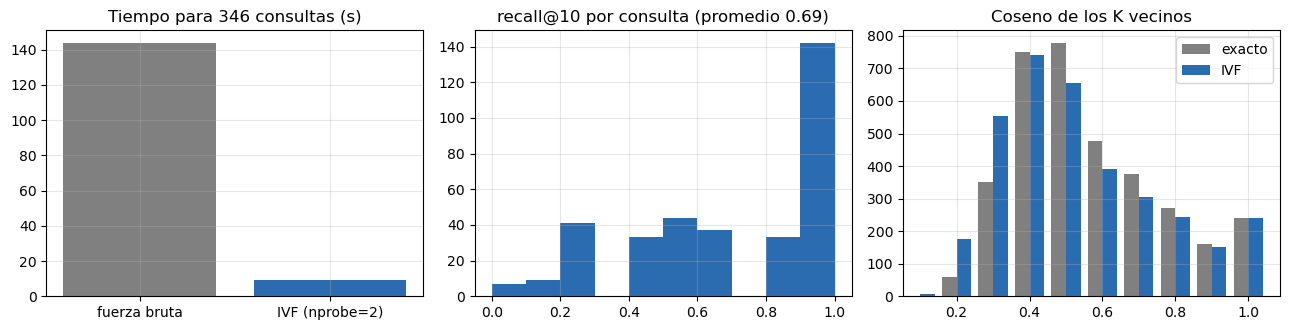

In [10]:
r_q = (exacto.join(ivf_e.select("ocid_q", "ocid_v", F.lit(1).alias("hit")), ["ocid_q", "ocid_v"], "left")
             .groupBy("ocid_q").agg((F.sum(F.coalesce("hit", F.lit(0))) / F.count("*")).alias("recall")).toPandas())
dist_ex = exacto.where("cos_sim >= 0").select(F.round("cos_sim", 1).alias("c")).groupBy("c").count().orderBy("c").toPandas()
dist_iv = ivf_e.where("cos_sim >= 0").select(F.round("cos_sim", 1).alias("c")).groupBy("c").count().orderBy("c").toPandas()

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].bar(["fuerza bruta", f"IVF (nprobe={NPROBE})"], [t_exacto, t_ivf_e], color=["gray", "#2b6cb0"]); ax[0].set_title(f"Tiempo para {n_e} consultas (s)")
ax[1].hist(r_q["recall"], bins=np.linspace(0, 1, 11), color="#2b6cb0"); ax[1].set_title(f"recall@{K} por consulta (promedio {recall:.2f})")
ax[2].bar(dist_ex["c"] - .02, dist_ex["count"], width=.04, color="gray", label="exacto"); ax[2].bar(dist_iv["c"] + .02, dist_iv["count"], width=.04, color="#2b6cb0", label="IVF")
ax[2].set_title("Coseno de los K vecinos"); ax[2].legend(); plt.tight_layout(); plt.show()

- IVF revisa una fracción del índice (`NPROBE / NLIST`) y pierde los vecinos que cayeron en listas no visitadas: ese es el costo en recall. Subir `NPROBE` mejora el recall a cambio de más comparaciones
- Siguiente: `d_analisis_entidades_regiones.ipynb`

### 6. Cierre

In [11]:
spark.stop()